### Publication-ready grouped bar chart for WSSS vs Full-supervised
#### X-axis grouped by DATA ALLOCATION; COLOUR encodes MODEL.

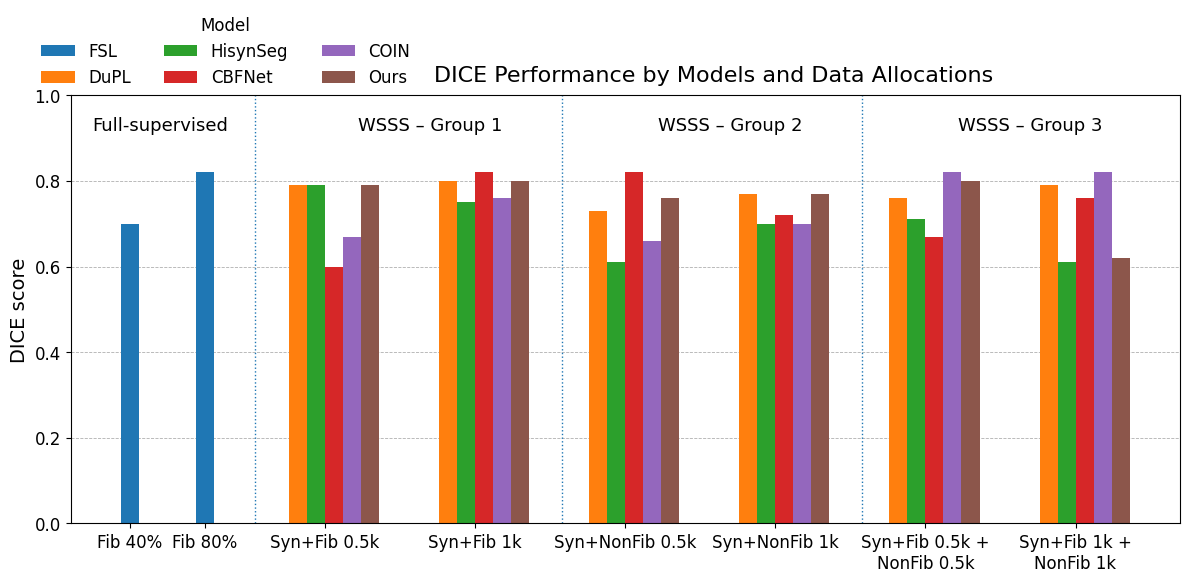

In [161]:
# -*- coding: utf-8 -*-
# Publication-ready grouped bar chart for WSSS vs Full-supervised
# X-axis grouped by DATA ALLOCATION; COLOUR encodes MODEL.
# One figure only; no seaborn; labels and vector exports included.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Define models & allocations
# ----------------------------
models = ["FSL", "DuPL", "HisynSeg", "CBFNet", "COIN", "Ours"]

allocations = [
    "Fib 40%",
    "Fib 80%",
    "Syn+Fib 0.5k",
    "Syn+Fib 1k",
    "Syn+NonFib 0.5k",
    "Syn+NonFib 1k",
    "Syn+Fib 0.5k +\nNonFib 0.5k",
    "Syn+Fib 1k +\nNonFib 1k",
]

value_labels=False

# ----------------------------
# 2) Insert your data
#    Shape: (n_models, n_allocations)
#    Use np.nan for impossible combos (e.g., WSSS under FullSup allocations; FullSup under WSSS allocations)
# ----------------------------
n_models = len(models)
n_allocs = len(allocations)
data = np.full((n_models, n_allocs), np.nan, dtype=float)

# Example (REPLACE with your real DICE scores)
# Full-supervised (only defined for Fibrosis 40% & 80%)
data[0, 0] = 0.70  # FullSup @ Fibrosis 40%
data[0, 1] = 0.82  # FullSup @ Fibrosis 80%

# WSSS models (only defined for the six WSSS allocations)
# Replace these with your model results; leaving FullSup columns as NaN.
example = {
    "DuPL": [0.79, 0.80, 0.73, 0.77, 0.76, 0.79],
    "HisynSeg": [0.79, 0.75, 0.61, 0.70, 0.71, 0.61],
    "CBFNet": [0.60, 0.82, 0.82, 0.72, 0.67, 0.76],
    "COIN": [0.67, 0.76, 0.66, 0.70, 0.82, 0.82],
    "Ours": [0.79, 0.80, 0.76, 0.77, 0.80, 0.62],
    # "Ours (Revised)": [0.81, 0.84, 0.78, 0.80, 0.83, 0.85],
}
for m_i, m in enumerate(models):
    if not m.startswith("F"):
        # Fill the last six allocations (indices 2..7)
        data[m_i, 2:] = example[m][:]

# ----------------------------
# 3) Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Adjust x positions to compress FSL section
x_positions = [0, 0.5, 1.35, 2.35, 3.35, 4.35, 5.35, 6.35]  # Custom spacing
x_positions = [x-0.05 if x > 1 else x for x in x_positions ]
x = np.array(x_positions)
bar_w = 0.12
offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

# Draw bars - special handling for FullSup to center them
for m_i, m in enumerate(models):
    y = data[m_i]
    valid = ~np.isnan(y)

    if m == "FSL":
        # Center FSL bars at their x positions (no offset)
        ax.bar(x[valid], y[valid], width=bar_w, label=m)

        # Value labels for FSL (centered)
        if value_labels:
            for j in np.where(valid)[0]:
                ax.text(
                    x[j], y[j] + 0.012, f"{y[j]:.2f}",
                    ha="center", va="bottom", fontsize=8
                )
    else:
        # WSSS models use offsets as before
        ax.bar(x[valid] + offsets[m_i], y[valid], width=bar_w, label=m)
        
        # Value labels for WSSS models
        if value_labels:
            for j in np.where(valid)[0]:
                ax.text(
                    x[j] + offsets[m_i], y[j] + 0.012, f"{y[j]:.2f}",
                    ha="center", va="bottom", fontsize=8
                )

# Axes, ticks, limits
ax.set_ylabel("DICE score", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(allocations, fontsize=12)
ax.set_ylim(0, 1.00)

# Increase y-axis tick label font size
ax.tick_params(axis='y', labelsize=12)

# Subtle grid and layering
ax.yaxis.grid(True, linestyle="--", linewidth=0.6)
ax.set_axisbelow(True)

# Visual separators & headers for blocks
for v in np.array([0.95, 3, 5])-0.12:
    ax.axvline(v, linestyle=":", linewidth=1.0)

ax.text(0.2, 0.95, "Full-supervised", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=13)  # Centered between 0 and 0.8
ax.text(2.0, 0.95, "WSSS – Group 1", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=13)  # Centered between 1.5 and 2.5
ax.text(4.0, 0.95, "WSSS – Group 2", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=13)  # Centered between 3.5 and 4.5
ax.text(6.0, 0.95, "WSSS – Group 3", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=13)  # Centered between 5.5 and 6.5

# Legend & title
ax.legend(title="Model", ncol=3, frameon=False, loc="upper left", bbox_to_anchor=(-0.04, 1.22), fontsize=12, title_fontsize=12)
ax.set_title("DICE Performance by Models and Data Allocations", pad=10, x=0.58, fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 1])  # leave right space for legend

# ----------------------------
# 4) Save exports
# ----------------------------
fig.savefig("../imgs/wsss_grouped_by_allocation_with_labels.png", dpi=300, bbox_inches="tight")
# fig.savefig("wsss_grouped_by_allocation_with_labels.pdf", bbox_inches="tight")
# fig.savefig("wsss_grouped_by_allocation_with_labels.svg", bbox_inches="tight")

plt.show()